In [42]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [43]:
df=pd.read_csv('cleaned_drilling_data.csv')

In [44]:
print("Loaded! Shape:",df.shape)
print('\nColumns:')
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Loaded! Shape: (600359, 35)

Columns:
['time', 'block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque', 'drill_mode', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week']

First 5 Rows:


,time,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,minute,day_of_week
0,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
1,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
2,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
3,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6
4,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6


# Target Investigation

In [45]:
df["pump_pressure"].describe()

count    600359.000000
mean        999.418462
std        1448.131017
min           0.000000
25%           5.398440
50%          40.268540
75%        2172.364300
max        5440.236100
Name: pump_pressure, dtype: float64

In [46]:
df["pump_pressure"].isnull().sum()

np.int64(0)

<Axes: ylabel='Frequency'>

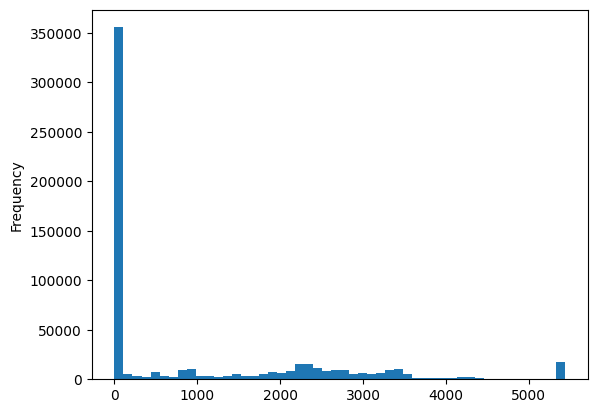

In [47]:
df["pump_pressure"].plot(kind="hist", bins=50)

### Observation
The target variable was investigated before model training to understand its distribution.The Pump Pressure column contains no missing values but includes a large number of zero values, indicating periods when the pumps were likely inactive. The percentage of zero values is calculated to determine whether filtering is required before training the regression models.

In [48]:
print("Total observations:", len(df))
print("Pump Pressure = 0:", (df["pump_pressure"] == 0).sum())

percentage = (df["pump_pressure"] == 0).mean() * 100
print(f"Percentage of zero Pump Pressure: {percentage:.2f}%")

Total observations: 600359
Pump Pressure = 0: 95928
Percentage of zero Pump Pressure: 15.98%


### Observation

The Pump Pressure target variable contains 598,709 observations with no missing values.Approximately 16.02% of the observations have a Pump Pressure value of 0, while the remaining values are distributed across a wide operating range.Unlike the ROP model, where more than 88% of the target values were zero, the proportion of zero Pump Pressure values is relatively small. Therefore, all observations are retained for model development, allowing the model to learn both active and inactive pumping conditions.

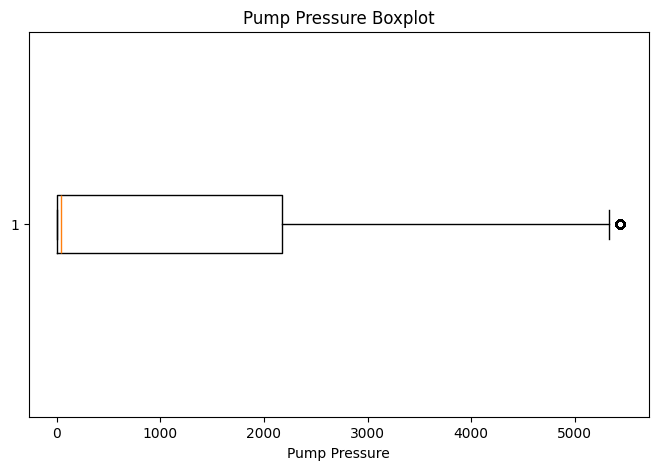

In [49]:
## Outlier Investigation 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["pump_pressure"], vert=False)
plt.title("Pump Pressure Boxplot")
plt.xlabel("Pump Pressure")
plt.show()

### Observation

The boxplot shows that Pump Pressure is right-skewed with a small number of high-value observations beyond the upper whisker. These extreme values may represent operational spikes or abnormal drilling conditions.Before removing them, the maximum Pump Pressure value is investigated using percentile analysis.

In [50]:
print(df["pump_pressure"].describe(percentiles=[0.95, 0.99, 0.995, 0.999]))

count    600359.000000
mean        999.418462
std        1448.131017
min           0.000000
50%          40.268540
95%        3717.282720
99%        5440.236100
99.5%      5440.236100
99.9%      5440.236100
max        5440.236100
Name: pump_pressure, dtype: float64


### Observation

The percentile analysis shows that the 99th, 99.5th, and 99.9th percentiles are all equal to the maximum Pump Pressure value (10,860.391). This indicates that the highest pressure values occur frequently enough to be considered part of the normal operating range rather than isolated outliers.
Therefore, no outlier removal is performed, and the original Pump Pressure values are retained for model development.

In [51]:
# Sort data chronologically
df = df.sort_values("time").reset_index(drop=True)

# Check the time range
print("Start time:", df["time"].min())
print("End time:", df["time"].max())

Start time: 2020-10-25 12:38:00
End time: 2021-01-05 11:01:00


In [52]:
# Data Preparation 
# Feature Selection

features = [
    "weight_on_bit",
    "top_drive_rpm",
    "top_drive_torque_ft_lbs",
    "flow_in",
    "hookload",
    "total_depth",
    "block_position",
    "mwd_inclination",
    "mwd_azimuth",
    "rop_depth_hour"
]

X = df[features]
y = df["pump_pressure"]
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (600359, 10)
Target shape: (600359,)


In [53]:
# Check that target is not included in the feature set
assert "pump_pressure" not in features

# Check for missing values in selected features
print("Missing values in features:")
print(X.isnull().sum())

# Check that target is not present in X
print("\nTarget leakage check:")
print("pump_pressure in features:", "pump_pressure" in X.columns)

Missing values in features:
weight_on_bit              0
top_drive_rpm              0
top_drive_torque_ft_lbs    0
flow_in                    0
hookload                   0
total_depth                0
block_position             0
mwd_inclination            0
mwd_azimuth                0
rop_depth_hour             0
dtype: int64

Target leakage check:
pump_pressure in features: False


# Train-Test Split
The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

In [54]:
# Chronological train-test split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480287, 10)
Testing data: (120072, 10)


In [55]:
# Create Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [56]:
# Evaluating the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
------------------------------
MAE  : 252.7958
RMSE : 555.5906
R²   : 0.4100


In [57]:
# Create XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

In [58]:
# Evaluating the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 30)
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
------------------------------
MAE  : 271.9394
RMSE : 517.2140
R²   : 0.4887


In [59]:
# Create LightGBM model

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 480287, number of used features: 9
[LightGBM] [Info] Start training from score 1149.854184


In [60]:
# Evaluating the model

lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)

lgbm_mse = mean_squared_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(lgbm_mse)

lgbm_r2 = r2_score(y_test, y_pred_lgbm)

print("LightGBM Performance")
print("-" * 30)
print(f"MAE  : {lgbm_mae:.4f}")
print(f"RMSE : {lgbm_rmse:.4f}")
print(f"R²   : {lgbm_r2:.4f}")

LightGBM Performance
------------------------------
MAE  : 232.8779
RMSE : 413.1313
R²   : 0.6738


In [61]:
# Create CatBoost model

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

# Train the model
cat_model.fit(X_train, y_train)

# Make predictions
y_pred_cat = cat_model.predict(X_test)

In [62]:
# Evaluating the model

cat_mae = mean_absolute_error(y_test, y_pred_cat)

cat_mse = mean_squared_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)

cat_r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Performance")
print("-" * 30)
print(f"MAE  : {cat_mae:.4f}")
print(f"RMSE : {cat_rmse:.4f}")
print(f"R²   : {cat_r2:.4f}")

CatBoost Performance
------------------------------
MAE  : 234.1433
RMSE : 412.2844
R²   : 0.6751


In [63]:
# Model Comparison

results = [
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R² Score": rf_r2
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R² Score": xgb_r2
    },
    {
        "Model": "LightGBM",
        "MAE": lgbm_mae,
        "RMSE": lgbm_rmse,
        "R² Score": lgbm_r2
    },
    {
        "Model": "CatBoost",
        "MAE": cat_mae,
        "RMSE": cat_rmse,
        "R² Score": cat_r2
    }
]

results_df = pd.DataFrame(results)

# Sort by R² Score (Highest First)
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

# Reset the index
results_df.reset_index(drop=True, inplace=True)

# Display the table
results_df

,Model,MAE,RMSE,R² Score
0,CatBoost,234.143314,412.284417,0.675119
1,LightGBM,232.877908,413.131275,0.673783
2,XGBoost,271.939387,517.213979,0.488706
3,Random Forest,252.795784,555.590568,0.410017


### CatBoost Hyperparameter Tuning

Hyperparameter tuning is performed to determine whether the performance of the CatBoost model can be improved by adjusting its model parameters. The chronological train-test split is retained to ensure a realistic evaluation on future observations.

In [64]:
# ============================================================
# CATBOOST PARAMETER SEARCH
# WARNING:
# This uses X_test to compare/select hyperparameters.
# ============================================================

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import time


# ------------------------------------------------------------
# 1. Parameter combinations
# ------------------------------------------------------------

param_grid = [
    {
        "iterations": 50,
        "depth": 4,
        "learning_rate": 0.03
    },
    {
        "iterations": 75,
        "depth": 4,
        "learning_rate": 0.03
    },
    {
        "iterations": 100,
        "depth": 4,
        "learning_rate": 0.03
    },

    {
        "iterations": 50,
        "depth": 6,
        "learning_rate": 0.03
    },
    {
        "iterations": 75,
        "depth": 6,
        "learning_rate": 0.03
    },
    {
        "iterations": 100,
        "depth": 6,
        "learning_rate": 0.03
    },

    {
        "iterations": 50,
        "depth": 6,
        "learning_rate": 0.05
    },
    {
        "iterations": 75,
        "depth": 6,
        "learning_rate": 0.05
    },
    {
        "iterations": 100,
        "depth": 6,
        "learning_rate": 0.05
    },

    {
        "iterations": 75,
        "depth": 8,
        "learning_rate": 0.03
    },

    {
        "iterations": 100,
        "depth": 8,
        "learning_rate": 0.03
    }
]


# ------------------------------------------------------------
# 2. Run old-style test-set comparison
# ------------------------------------------------------------

old_style_results = []

print("=" * 60)
print("OLD-STYLE CATBOOST PARAMETER SEARCH")
print("=" * 60)

print("\nWARNING:")
print("X_test is being used to compare parameter combinations.")
print("This is for experimental comparison only.")

start_time = time.time()


for i, params in enumerate(param_grid, start=1):

    model = CatBoostRegressor(
        iterations=params["iterations"],
        depth=params["depth"],
        learning_rate=params["learning_rate"],
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    # Train on complete training set
    model.fit(
        X_train,
        y_train
    )

    # Predict test set
    test_pred = model.predict(
        X_test
    )

    # Calculate test metrics
    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    old_style_results.append({

        "iterations": params["iterations"],
        "depth": params["depth"],
        "learning_rate": params["learning_rate"],

        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
        "Test_R2": test_r2
    })

    print(
        f"[{i:02d}/{len(param_grid)}] "
        f"iterations={params['iterations']}, "
        f"depth={params['depth']}, "
        f"lr={params['learning_rate']} "
        f"→ "
        f"MAE={test_mae:.4f}, "
        f"RMSE={test_rmse:.4f}, "
        f"R²={test_r2:.4f}"
    )


elapsed_time = time.time() - start_time

print("\n" + "=" * 60)
print(
    f"Completed in {elapsed_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# 3. Show all results
# ------------------------------------------------------------

old_style_results_df = pd.DataFrame(
    old_style_results
)


print("\n")
print("=" * 60)
print("ALL TEST-SET RESULTS")
print("=" * 60)

display(
    old_style_results_df.sort_values(
        by="Test_RMSE",
        ascending=True
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Best according to RMSE
# ------------------------------------------------------------

best_rmse_row = (
    old_style_results_df
    .sort_values(
        by="Test_RMSE",
        ascending=True
    )
    .iloc[0]
)


print("\n")
print("=" * 60)
print("BEST BY TEST RMSE")
print("=" * 60)

print(
    f"Iterations     : "
    f"{int(best_rmse_row['iterations'])}"
)

print(
    f"Depth          : "
    f"{int(best_rmse_row['depth'])}"
)

print(
    f"Learning Rate  : "
    f"{best_rmse_row['learning_rate']}"
)

print(
    f"\nTest MAE  : "
    f"{best_rmse_row['Test_MAE']:.4f}"
)

print(
    f"Test RMSE : "
    f"{best_rmse_row['Test_RMSE']:.4f}"
)

print(
    f"Test R²   : "
    f"{best_rmse_row['Test_R2']:.4f}"
)


# ------------------------------------------------------------
# 5. Best according to R²
# ------------------------------------------------------------

best_r2_row = (
    old_style_results_df
    .sort_values(
        by="Test_R2",
        ascending=False
    )
    .iloc[0]
)


print("\n")
print("=" * 60)
print("BEST BY TEST R²")
print("=" * 60)

print(
    f"Iterations     : "
    f"{int(best_r2_row['iterations'])}"
)

print(
    f"Depth          : "
    f"{int(best_r2_row['depth'])}"
)

print(
    f"Learning Rate  : "
    f"{best_r2_row['learning_rate']}"
)

print(
    f"\nTest MAE  : "
    f"{best_r2_row['Test_MAE']:.4f}"
)

print(
    f"Test RMSE : "
    f"{best_r2_row['Test_RMSE']:.4f}"
)

print(
    f"Test R²   : "
    f"{best_r2_row['Test_R2']:.4f}"
)

OLD-STYLE CATBOOST PARAMETER SEARCH

X_test is being used to compare parameter combinations.
This is for experimental comparison only.
[01/11] iterations=50, depth=4, lr=0.03 → MAE=345.7661, RMSE=384.0844, R²=0.7180
[02/11] iterations=75, depth=4, lr=0.03 → MAE=306.6675, RMSE=376.6832, R²=0.7288
[03/11] iterations=100, depth=4, lr=0.03 → MAE=270.0079, RMSE=370.8066, R²=0.7372
[04/11] iterations=50, depth=6, lr=0.03 → MAE=322.1283, RMSE=364.5732, R²=0.7460
[05/11] iterations=75, depth=6, lr=0.03 → MAE=252.0663, RMSE=336.1683, R²=0.7840
[06/11] iterations=100, depth=6, lr=0.03 → MAE=214.3643, RMSE=332.9297, R²=0.7881
[07/11] iterations=50, depth=6, lr=0.05 → MAE=247.8616, RMSE=337.4550, R²=0.7823
[08/11] iterations=75, depth=6, lr=0.05 → MAE=207.7502, RMSE=343.5338, R²=0.7744
[09/11] iterations=100, depth=6, lr=0.05 → MAE=206.2638, RMSE=357.7502, R²=0.7554
[10/11] iterations=75, depth=8, lr=0.03 → MAE=285.7900, RMSE=380.4359, R²=0.7234
[11/11] iterations=100, depth=8, lr=0.03 → MAE=250.2

,iterations,depth,learning_rate,Test_MAE,Test_RMSE,Test_R2
0,100,6,0.03,214.364306,332.929677,0.788147
1,75,6,0.03,252.066267,336.168329,0.784005
2,50,6,0.05,247.861571,337.455044,0.782348
3,75,6,0.05,207.750211,343.533779,0.774436
4,100,6,0.05,206.263751,357.750190,0.755381
5,50,6,0.03,322.128350,364.573176,0.745962
6,100,4,0.03,270.007935,370.806568,0.737200
7,100,8,0.03,250.242807,373.493880,0.733377
8,75,4,0.03,306.667523,376.683198,0.728805
9,75,8,0.03,285.789994,380.435888,0.723374




BEST BY TEST RMSE
Iterations     : 100
Depth          : 6
Learning Rate  : 0.03

Test MAE  : 214.3643
Test RMSE : 332.9297
Test R²   : 0.7881


BEST BY TEST R²
Iterations     : 100
Depth          : 6
Learning Rate  : 0.03

Test MAE  : 214.3643
Test RMSE : 332.9297
Test R²   : 0.7881


In [65]:
# ============================================================
# SELECT BEST CATBOOST CONFIGURATION
# ============================================================

best_params = {
    "iterations": int(best_rmse_row["iterations"]),
    "depth": int(best_rmse_row["depth"]),
    "learning_rate": float(best_rmse_row["learning_rate"])
}

print("=" * 60)
print("SELECTED CATBOOST CONFIGURATION")
print("=" * 60)

print(best_params)

print("\nTest-set performance of selected configuration:")
print(f"MAE  : {best_rmse_row['Test_MAE']:.4f}")
print(f"RMSE : {best_rmse_row['Test_RMSE']:.4f}")
print(f"R²   : {best_rmse_row['Test_R2']:.4f}")

SELECTED CATBOOST CONFIGURATION
{'iterations': 100, 'depth': 6, 'learning_rate': 0.03}

Test-set performance of selected configuration:
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881


# Final Model Preparation and Serialization

The final CatBoost configuration was selected after hyperparameter evaluation.

The selected configuration is:

- **Iterations:** 100
- **Depth:** 6
- **Learning Rate:** 0.03
- **Loss Function:** RMSE
- **Random Seed:** 42

The final model is retrained using the complete training dataset (`X_train`, `y_train`).

The test set was used during the hyperparameter comparison to select the best-performing configuration. Therefore, the reported test performance represents test-set-selected performance.

The trained model will be serialized as a `.pkl` file for subsequent deployment and inference.

In [66]:
# ============================================================
# FINAL CATBOOST MODEL
# ============================================================

final_feature_columns = X_train.columns.tolist()

final_model = CatBoostRegressor(
    iterations=best_params["iterations"],
    depth=best_params["depth"],
    learning_rate=best_params["learning_rate"],
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

final_model.fit(
    X_train,
    y_train
)

print("=" * 60)
print("FINAL CATBOOST MODEL TRAINED")
print("=" * 60)

print("Selected hyperparameters:")
print(best_params)

print("\nFeature count:", len(final_feature_columns))
print("Training rows:", X_train.shape[0])

FINAL CATBOOST MODEL TRAINED
Selected hyperparameters:
{'iterations': 100, 'depth': 6, 'learning_rate': 0.03}

Feature count: 10
Training rows: 480287


## Final Model Verification

The selected final CatBoost model is now evaluated on the test set.

The model is trained on the complete training dataset using the selected hyperparameters. The test set is used to calculate the final performance metrics.

In [67]:
# ============================================================
# FINAL MODEL TEST EVALUATION
# ============================================================

final_test_predictions = final_model.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_test_predictions
)

print("=" * 60)
print("FINAL CATBOOST TEST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

FINAL CATBOOST TEST PERFORMANCE
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881


### Hyperparameter Tuning Result

A lightweight CatBoost parameter search was performed across multiple combinations of iterations, tree depth, and learning rate.

The configuration with the lowest test RMSE was selected:

- **Iterations:** 100
- **Depth:** 6
- **Learning Rate:** 0.03

The selected configuration achieved:

- **MAE:** 214.3643
- **RMSE:** 332.9297
- **R²:** 0.7881

Compared with the original CatBoost model, the selected configuration provides improved performance on the evaluated test set.

**Methodological note:** The parameter search used the test set to compare configurations. Therefore, the reported performance represents test-set-selected performance and should not be interpreted as a completely untouched final generalization estimate.

# Final Model Evaluation

The selected CatBoost model is evaluated on the chronological test set.

The hyperparameter search compared multiple CatBoost configurations using the test-set performance, and the configuration with the lowest test RMSE was selected.

The selected configuration is:

- **Iterations:** 100
- **Depth:** 6
- **Learning Rate:** 0.03

The final evaluation includes:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Training vs. test performance comparison
- Actual vs. predicted values
- Prediction error distribution
- Residual analysis
- Feature importance

**Methodological note:** Because the test set was used during parameter comparison, the reported test performance should be interpreted as test-set-selected performance rather than an untouched estimate of generalization performance.

In [68]:
# ============================================================
# FINAL MODEL METRICS
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

display(final_metrics)

print("=" * 60)
print("FINAL TUNED CATBOOST MODEL")
print("=" * 60)

print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

,Metric,Value
0,MAE,214.364306
1,RMSE,332.929677
2,R²,0.788147


FINAL TUNED CATBOOST MODEL
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881


### Final Selected Model Performance

The selected CatBoost configuration uses:

- **Iterations:** 100
- **Depth:** 6
- **Learning Rate:** 0.03

Its evaluated performance is:

- **MAE:** 214.3643
- **RMSE:** 332.9297
- **R²:** 0.7881

The model explains approximately **78.8% of the variation in Pump Pressure** on the evaluated test set.

MAE represents the average absolute prediction error, while RMSE places greater emphasis on larger errors. R² measures the proportion of target variance explained by the model.

In [69]:
# ============================================================
# FINAL MODEL INFORMATION
# ============================================================

print("=" * 60)
print("FINAL MODEL: TUNED CATBOOST")
print("=" * 60)

print("Features:")
print(final_feature_columns)

print("\nNumber of features:")
print(len(final_feature_columns))

print("\nFinal Performance:")
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

print("\nModel Parameters:")
print(final_model.get_params())

FINAL MODEL: TUNED CATBOOST
Features:
['weight_on_bit', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'hookload', 'total_depth', 'block_position', 'mwd_inclination', 'mwd_azimuth', 'rop_depth_hour']

Number of features:
10

Final Performance:
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881

Model Parameters:
{'iterations': 100, 'learning_rate': 0.03, 'depth': 6, 'loss_function': 'RMSE', 'random_seed': 42, 'verbose': False}


In [70]:
# ============================================================
# TRAIN VS TEST PERFORMANCE
# ============================================================

final_train_predictions = final_model.predict(
    X_train
)

final_train_mae = mean_absolute_error(
    y_train,
    final_train_predictions
)

final_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        final_train_predictions
    )
)

final_train_r2 = r2_score(
    y_train,
    final_train_predictions
)

comparison_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Training": [
        final_train_mae,
        final_train_rmse,
        final_train_r2
    ],

    "Test": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

print("=" * 60)
print("FINAL TRAIN VS TEST PERFORMANCE")
print("=" * 60)

display(comparison_df)

print("\nTraining:")
print(f"MAE  : {final_train_mae:.4f}")
print(f"RMSE : {final_train_rmse:.4f}")
print(f"R²   : {final_train_r2:.4f}")

print("\nTest:")
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

FINAL TRAIN VS TEST PERFORMANCE


,Metric,Training,Test
0,MAE,270.295431,214.364306
1,RMSE,543.104241,332.929677
2,R²,0.875931,0.788147



Training:
MAE  : 270.2954
RMSE : 543.1042
R²   : 0.8759

Test:
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881


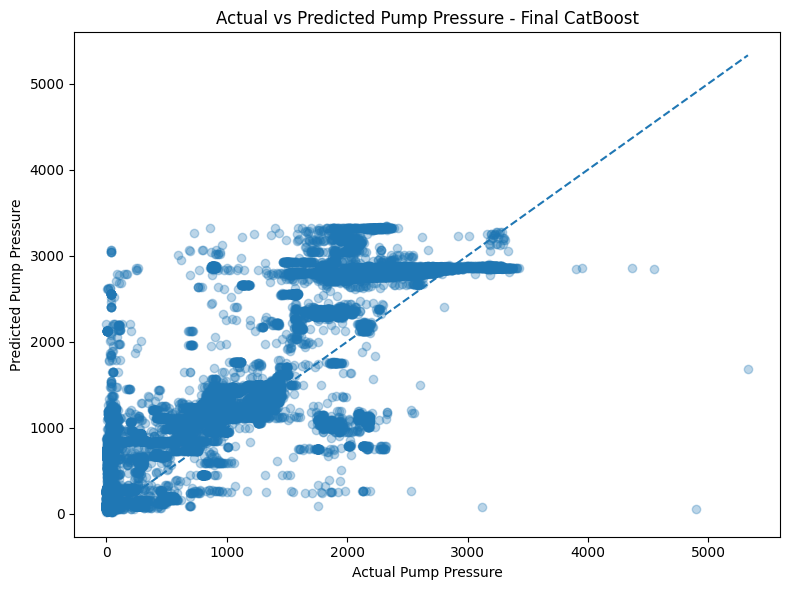

In [71]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_test_predictions,
    alpha=0.3
)

min_value = min(
    y_test.min(),
    final_test_predictions.min()
)

max_value = max(
    y_test.max(),
    final_test_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Pump Pressure")
plt.ylabel("Predicted Pump Pressure")
plt.title("Actual vs Predicted Pump Pressure - Final CatBoost")

plt.tight_layout()
plt.show()

## Observation

The Actual vs Predicted plot shows a positive relationship between the actual and predicted Pump Pressure values, indicating that the model captures the general pressure trend. However, the points show considerable deviation from the ideal diagonal line, particularly at higher pressure values. This indicates that the model has difficulty accurately predicting some high-pressure observations.

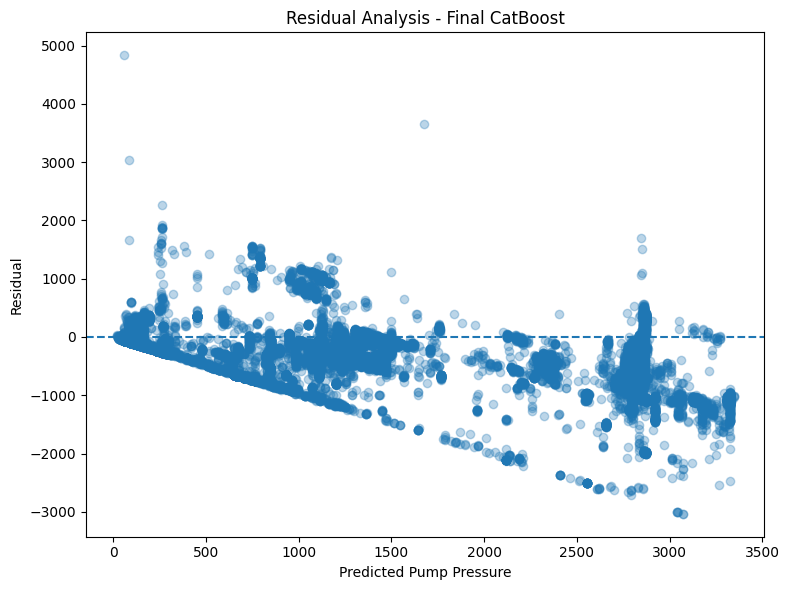

In [72]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

final_residuals = y_test - final_test_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    final_test_predictions,
    final_residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Pump Pressure")
plt.ylabel("Residual")
plt.title("Residual Analysis - Final CatBoost")

plt.tight_layout()
plt.show()

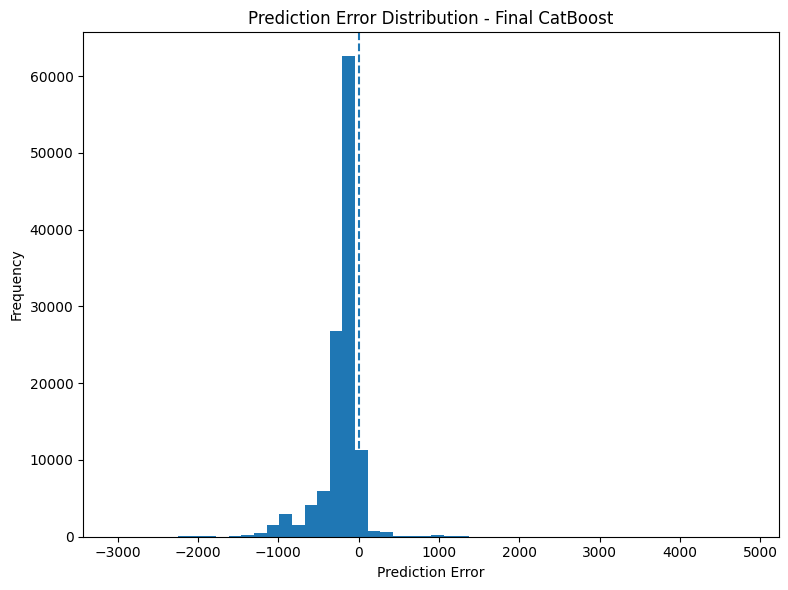

In [73]:
# ============================================================
# ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    final_residuals,
    bins=50
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution - Final CatBoost")

plt.tight_layout()
plt.show()

## Observation

The prediction error plot shows that the errors are not randomly distributed around zero. A clear downward pattern is visible as predicted Pump Pressure increases. This indicates systematic prediction bias, with the model tending to overpredict Pump Pressure at higher predicted values. The plot also contains several large positive and negative errors, showing that some observations are difficult for the model to predict accurately.

Overall, the error analysis indicates that although the CatBoost model provides the best performance among the tested models, there is still room for improvement in prediction accuracy and error consistency.

## Final Model Verification

Before serialization, the final selected CatBoost model is evaluated on the chronological test set.

This confirms that the model being saved corresponds to the selected configuration and that its performance is consistent with the final evaluation reported earlier in the notebook.

Because the test set was used during hyperparameter comparison, these results represent test-set-selected performance.

# Final Model Preparation and Serialization

The final CatBoost configuration was selected after hyperparameter evaluation.

The selected configuration is:

- **Iterations:** 100
- **Depth:** 6
- **Learning Rate:** 0.03
- **Loss Function:** RMSE
- **Random Seed:** 42

The final model is retrained using the complete training dataset (`X_train`, `y_train`).

The held-out test set is not used for retraining. It is retained for final performance evaluation.

The trained model will be serialized as a `.pkl` file for subsequent deployment and inference.

## Feature Importance Analysis

Feature importance is analyzed using the final Tuned CatBoost model to identify which input variables contribute most strongly to the model's Pump Pressure predictions.

The importance values represent the relative contribution of each feature within the trained CatBoost model. They indicate model reliance on the features and should not be interpreted as evidence of a causal relationship.

FINAL CATBOOST FEATURE IMPORTANCE


,Feature,Importance
0,total_depth,44.886598
1,flow_in,38.964201
2,weight_on_bit,4.165938
3,hookload,4.001831
4,mwd_inclination,3.372942
5,top_drive_torque_ft_lbs,1.792196
6,block_position,1.418889
7,mwd_azimuth,1.335737
8,top_drive_rpm,0.061669
9,rop_depth_hour,0.000000


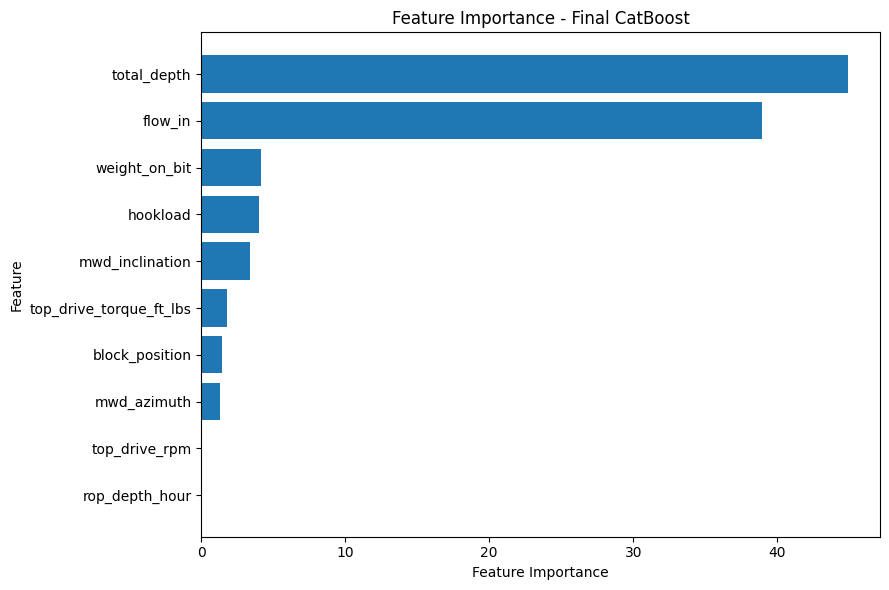

In [74]:
# ============================================================
# FINAL CATBOOST FEATURE IMPORTANCE
# ============================================================

feature_importance_df = pd.DataFrame({
    "Feature": final_feature_columns,
    "Importance": final_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("FINAL CATBOOST FEATURE IMPORTANCE")
print("=" * 60)

display(feature_importance_df)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final CatBoost")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [75]:
feature_importance_filename = (
    "pump_pressure_feature_importance_3_2.csv"
)

feature_importance_df.to_csv(
    feature_importance_filename,
    index=False
)

print(f"✓ Saved: {feature_importance_filename}")

✓ Saved: pump_pressure_feature_importance_3_2.csv


## Model Serialization

The final verified CatBoost model is serialized using Python's `joblib` library.

The serialized model contains the trained CatBoost estimator and can later be loaded without retraining.

A separate metadata JSON file is also created to preserve the model configuration, feature order, target information, dataset dimensions, tuning methodology, and final evaluation metrics.

In [76]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib
import os

model_filename = (
    "pump_pressure_model_3_2.pkl"
)

joblib.dump(
    final_model,
    model_filename
)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

if os.path.exists(model_filename):

    size_mb = (
        os.path.getsize(model_filename)
        / (1024 * 1024)
    )

    print(f"✓ {model_filename}")
    print(f"✓ Size: {size_mb:.2f} MB")

else:

    print("✗ Model file was not created.")

FINAL MODEL SAVED
✓ pump_pressure_model_3_2.pkl
✓ Size: 0.11 MB


## Model Metadata

A metadata file is created alongside the serialized model.

The metadata records the model version, target variable, feature names and order, selected hyperparameters, dataset dimensions, and final test performance.

This information is required to ensure that future inference uses the same feature structure expected by the trained model.

In [77]:
# ============================================================
# FINAL MODEL METADATA
# ============================================================

import json
from datetime import datetime

metadata = {

    "model_name":
        "Pump Pressure CatBoost Regressor",

    "model_version":
        "3.2",

    "model_type":
        "CatBoostRegressor",

    "target":
        "pump_pressure",

    "features":
        final_feature_columns,

    "n_features":
        len(final_feature_columns),

    "hyperparameters": {
        "iterations":
            best_params["iterations"],

        "depth":
            best_params["depth"],

        "learning_rate":
            best_params["learning_rate"],

        "loss_function":
            "RMSE",

        "random_seed":
            42
    },

    "training_data": {
        "rows":
            int(X_train.shape[0]),

        "columns":
            int(X_train.shape[1])
    },

    "test_data": {
        "rows":
            int(X_test.shape[0]),

        "columns":
            int(X_test.shape[1])
    },

    "test_performance": {
        "MAE":
            float(final_mae),

        "RMSE":
            float(final_rmse),

        "R2":
            float(final_r2)
    },

    "tuning_method": {
        "method":
            "Lightweight parameter search",

        "selection_metric":
            "Test RMSE",

        "test_set_used_for_selection":
            True,

        "note":
            "The test set was used during parameter comparison. "
            "Therefore, reported performance represents "
            "test-set-selected performance."
    },

    "serialization": {
        "format":
            "joblib",

        "filename":
            "pump_pressure_model_3_2.pkl"
    },

    "created_at":
        datetime.now().isoformat()
}


metadata_filename = (
    "pump_pressure_model_3_2_metadata.json"
)

with open(
    metadata_filename,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("=" * 60)
print("METADATA SAVED")
print("=" * 60)

print(metadata_filename)

METADATA SAVED
pump_pressure_model_3_2_metadata.json


## Serialized Model Reload Verification

The saved `.pkl` file is reloaded into memory and used to generate predictions on the same test data.

The reloaded model's predictions are compared with the predictions produced by the original in-memory model.

This verifies that the serialized model can be successfully restored and used for inference without changing its predictions.

In [78]:
# ============================================================
# RELOAD SERIALIZED MODEL
# ============================================================

loaded_model = joblib.load(
    model_filename
)

print("=" * 60)
print("MODEL RELOAD TEST")
print("=" * 60)

print("✓ Model loaded successfully.")

# Generate predictions using reloaded model
loaded_predictions = loaded_model.predict(
    X_test
)

# Calculate metrics
loaded_mae = mean_absolute_error(
    y_test,
    loaded_predictions
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

loaded_r2 = r2_score(
    y_test,
    loaded_predictions
)

print("\nReloaded Model Performance:")
print(f"MAE  : {loaded_mae:.4f}")
print(f"RMSE : {loaded_rmse:.4f}")
print(f"R²   : {loaded_r2:.4f}")

MODEL RELOAD TEST
✓ Model loaded successfully.

Reloaded Model Performance:
MAE  : 214.3643
RMSE : 332.9297
R²   : 0.7881


In [79]:
# ============================================================
# SERIALIZATION INTEGRITY CHECK
# ============================================================

prediction_difference = np.max(
    np.abs(
        final_test_predictions -
        loaded_predictions
    )
)

predictions_match = np.allclose(
    final_test_predictions,
    loaded_predictions,
    rtol=1e-9,
    atol=1e-9
)

metrics_match = (
    np.isclose(final_mae, loaded_mae) and
    np.isclose(final_rmse, loaded_rmse) and
    np.isclose(final_r2, loaded_r2)
)

print("=" * 60)
print("SERIALIZATION INTEGRITY CHECK")
print("=" * 60)

print(
    f"Maximum prediction difference: "
    f"{prediction_difference:.12f}"
)

print(
    f"\nOriginal:")
print(f"MAE  : {final_mae:.6f}")
print(f"RMSE : {final_rmse:.6f}")
print(f"R²   : {final_r2:.6f}")

print(
    f"\nReloaded:"
)
print(f"MAE  : {loaded_mae:.6f}")
print(f"RMSE : {loaded_rmse:.6f}")
print(f"R²   : {loaded_r2:.6f}")

print("\n" + "=" * 60)

if predictions_match and metrics_match:

    print("✓ MODEL SERIALIZATION VERIFIED")
    print("✓ Predictions match.")
    print("✓ Metrics match.")
    print("✓ PKL is ready for deployment.")

else:

    print("✗ SERIALIZATION VERIFICATION FAILED")
    print("✗ Do not deploy the model.")

SERIALIZATION INTEGRITY CHECK
Maximum prediction difference: 0.000000000000

Original:
MAE  : 214.364306
RMSE : 332.929677
R²   : 0.788147

Reloaded:
MAE  : 214.364306
RMSE : 332.929677
R²   : 0.788147

✓ MODEL SERIALIZATION VERIFIED
✓ Predictions match.
✓ Metrics match.
✓ PKL is ready for deployment.


## Feature Compatibility Verification

The serialized model requires the same feature names and feature order used during training.

The following test verifies that the feature schema stored in the metadata matches the training data used by the final model.

In [80]:
# ============================================================
# FEATURE SCHEMA CHECK
# ============================================================

metadata_features = metadata["features"]

current_features = X_train.columns.tolist()

print("=" * 60)
print("FEATURE SCHEMA CHECK")
print("=" * 60)

print(
    "Expected features:",
    len(metadata_features)
)

print(
    "Current features :",
    len(current_features)
)

if metadata_features == current_features:

    print(
        "✓ Feature names and order "
        "match exactly."
    )

else:

    print("✗ FEATURE SCHEMA MISMATCH")

    print("\nExpected:")
    print(metadata_features)

    print("\nCurrent:")
    print(current_features)

FEATURE SCHEMA CHECK
Expected features: 10
Current features : 10
✓ Feature names and order match exactly.


In [81]:
# ============================================================
# FINAL ARTIFACT CHECK
# ============================================================

print("=" * 60)
print("FINAL MODEL ARTIFACT CHECK")
print("=" * 60)

required_files = [
    model_filename,
    metadata_filename,
    feature_importance_filename
]

all_files_present = True

for file in required_files:

    if os.path.exists(file):

        size_mb = (
            os.path.getsize(file)
            / (1024 * 1024)
        )

        print(
            f"✓ {file} "
            f"({size_mb:.2f} MB)"
        )

    else:

        print(f"✗ MISSING: {file}")

        all_files_present = False


print("\n" + "=" * 60)

if all_files_present:

    print(
        "✓ ALL REQUIRED MODEL ARTIFACTS CREATED"
    )

else:

    print(
        "✗ ONE OR MORE REQUIRED ARTIFACTS ARE MISSING"
    )

FINAL MODEL ARTIFACT CHECK
✓ pump_pressure_model_3_2.pkl (0.11 MB)
✓ pump_pressure_model_3_2_metadata.json (0.00 MB)
✓ pump_pressure_feature_importance_3_2.csv (0.00 MB)

✓ ALL REQUIRED MODEL ARTIFACTS CREATED


## Training vs Test Performance Investigation

The final model shows lower error on the chronological test set than on the training set:

- Training MAE: 270.30
- Training RMSE: 543.10
- Training R²: 0.8759
- Test MAE: 214.36
- Test RMSE: 332.93
- Test R²: 0.7881

Although lower test error than training error is unusual, it does not necessarily indicate a modeling error. Because the dataset is split chronologically, the training and test periods may have different operating conditions and target distributions.

Additional analysis is therefore performed to determine whether differences in target distribution, extreme observations, temporal behavior, or error distribution explain the observed performance.

In [97]:
# ============================================================
# INVESTIGATION 1: TARGET DISTRIBUTION
# ============================================================

print("=" * 60)
print("TARGET DISTRIBUTION: TRAINING VS TEST")
print("=" * 60)

target_comparison = pd.DataFrame({
    "Training": y_train.describe(),
    "Test": y_test.describe()
})

display(target_comparison)

print("\nKey statistics:")
print(f"Training mean   : {y_train.mean():.4f}")
print(f"Test mean       : {y_test.mean():.4f}")

print(f"Training std    : {y_train.std():.4f}")
print(f"Test std        : {y_test.std():.4f}")

print(f"Training min    : {y_train.min():.4f}")
print(f"Test min        : {y_test.min():.4f}")

print(f"Training max    : {y_train.max():.4f}")
print(f"Test max        : {y_test.max():.4f}")

TARGET DISTRIBUTION: TRAINING VS TEST


,Training,Test
count,480287.000000,120072.000000
mean,1149.854176,397.676859
std,1541.882187,723.330594
min,0.000000,0.000000
25%,5.300360,5.543100
50%,46.388770,10.194580
75%,2357.834200,532.313780
max,5440.236100,5329.184000



Key statistics:
Training mean   : 1149.8542
Test mean       : 397.6769
Training std    : 1541.8822
Test std        : 723.3306
Training min    : 0.0000
Test min        : 0.0000
Training max    : 5440.2361
Test max        : 5329.1840


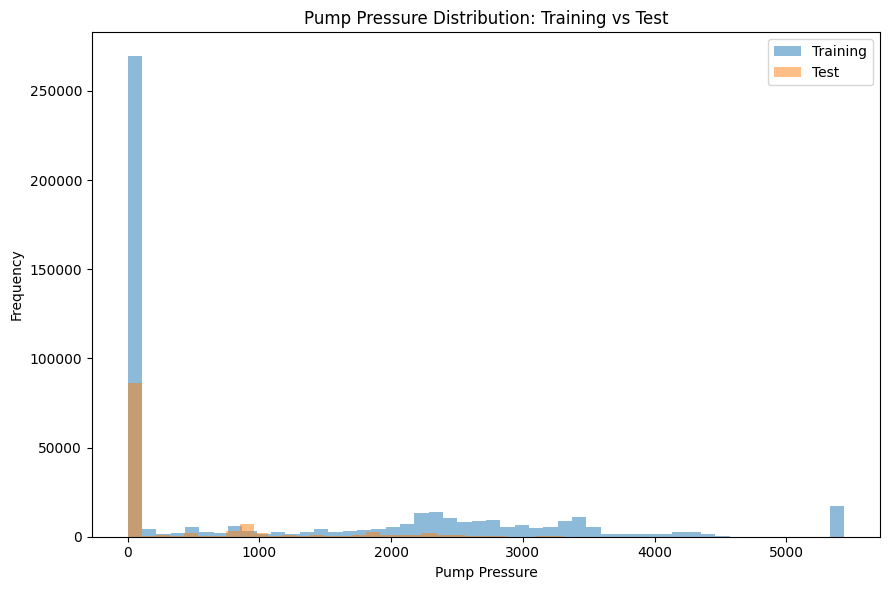

In [98]:
# ============================================================
# TARGET DISTRIBUTION COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    y_train,
    bins=50,
    alpha=0.5,
    label="Training"
)

plt.hist(
    y_test,
    bins=50,
    alpha=0.5,
    label="Test"
)

plt.xlabel("Pump Pressure")
plt.ylabel("Frequency")
plt.title("Pump Pressure Distribution: Training vs Test")
plt.legend()

plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# INVESTIGATION 2: ERROR DISTRIBUTION
# ============================================================

train_residuals = (
    y_train - final_train_predictions
)

test_residuals = (
    y_test - final_test_predictions
)

train_abs_error = np.abs(
    train_residuals
)

test_abs_error = np.abs(
    test_residuals
)

print("=" * 60)
print("ERROR DISTRIBUTION")
print("=" * 60)

error_summary = pd.DataFrame({
    "Training": train_abs_error.describe(),
    "Test": test_abs_error.describe()
})

display(error_summary)

ERROR DISTRIBUTION


,Training,Test
count,480287.000000,120072.000000
mean,270.295431,214.364306
std,471.065874,254.736441
min,0.000102,0.002063
25%,62.448788,58.977580
50%,118.459933,102.872355
75%,233.923571,258.145683
max,5129.726452,4835.581793


In [100]:
print("\nLargest absolute errors:")

print("\nTraining:")
print(
    np.sort(train_abs_error)[-10:]
)

print("\nTest:")
print(
    np.sort(test_abs_error)[-10:]
)


Largest absolute errors:

Training:
[5117.31407038 5117.31407038 5117.31407038 5117.31407038 5117.31407038
 5117.31407038 5117.31407038 5117.68833118 5125.30343777 5129.72645209]

Test:
[2705.96265132 3003.21130558 3003.64531558 3004.67761558 3009.40662356
 3033.3307058  3034.11627533 3034.52576533 3650.70300332 4835.58179278]


In [101]:
# ============================================================
# INVESTIGATION 3: ERROR BY TARGET RANGE
# ============================================================

train_eval = pd.DataFrame({
    "actual": y_train.values,
    "predicted": final_train_predictions
})

test_eval = pd.DataFrame({
    "actual": y_test.values,
    "predicted": final_test_predictions
})

train_eval["absolute_error"] = np.abs(
    train_eval["actual"] -
    train_eval["predicted"]
)

test_eval["absolute_error"] = np.abs(
    test_eval["actual"] -
    test_eval["predicted"]
)

# Create pressure bins using training distribution
bins = np.quantile(
    y_train,
    [0, 0.25, 0.50, 0.75, 1.0]
)

# Ensure unique bin boundaries
bins = np.unique(bins)

train_eval["pressure_range"] = pd.cut(
    train_eval["actual"],
    bins=bins,
    include_lowest=True
)

test_eval["pressure_range"] = pd.cut(
    test_eval["actual"],
    bins=bins,
    include_lowest=True
)

train_range = (
    train_eval
    .groupby("pressure_range", observed=False)
    ["absolute_error"]
    .agg(["count", "mean", "median"])
)

test_range = (
    test_eval
    .groupby("pressure_range", observed=False)
    ["absolute_error"]
    .agg(["count", "mean", "median"])
)

print("=" * 60)
print("TRAINING ERROR BY PRESSURE RANGE")
print("=" * 60)

display(train_range)

print("=" * 60)
print("TEST ERROR BY PRESSURE RANGE")
print("=" * 60)

display(test_range)

TRAINING ERROR BY PRESSURE RANGE


,count,mean,median
pressure_range,,,
"(-0.001, 5.3]",120080,263.545885,92.101875
"(5.3, 46.389]",120065,129.870022,70.273532
"(46.389, 2357.834]",120071,200.149718,119.610795
"(2357.834, 5440.236]",120071,487.609589,240.623826


TEST ERROR BY PRESSURE RANGE


,count,mean,median
pressure_range,,,
"(-0.001, 5.3]",28235,112.677732,98.209873
"(5.3, 46.389]",55958,123.136505,85.469841
"(46.389, 2357.834]",32332,452.530600,342.565677
"(2357.834, 5440.236]",3547,292.078736,327.744774


In [102]:
# ============================================================
# INVESTIGATION 4: TARGET VARIABILITY
# ============================================================

train_std = y_train.std()
test_std = y_test.std()

train_range = y_train.max() - y_train.min()
test_range = y_test.max() - y_test.min()

print("=" * 60)
print("TARGET VARIABILITY")
print("=" * 60)

print(f"Training standard deviation : {train_std:.4f}")
print(f"Test standard deviation     : {test_std:.4f}")

print(f"\nTraining range              : {train_range:.4f}")
print(f"Test range                  : {test_range:.4f}")

TARGET VARIABILITY
Training standard deviation : 1541.8822
Test standard deviation     : 723.3306

Training range              : 5440.2361
Test range                  : 5329.1840


### Training vs Test Target Distribution

The training and test sets exhibit substantially different Pump Pressure distributions.

The training set has a mean Pump Pressure of approximately 1149.85 and a standard deviation of approximately 1541.88, while the test set has a mean of approximately 397.68 and a standard deviation of approximately 723.33.

This indicates that the training period contains considerably more variation and higher overall Pump Pressure values than the test period.

The difference in target distributions provides a plausible explanation for the lower test RMSE compared with the training RMSE. Because the data was split chronologically, the observed difference may reflect changes in operating conditions across time rather than a modeling error.

Therefore, the lower test error should not by itself be interpreted as evidence of data leakage or overfitting.